# 1. Environment Exploration & MDP Formalization

This notebook systematically probes all three PyFlyt environments across every relevant dimension needed for a complete MDP formalization:

| Section | What we measure |
|---|---|
| **1. Spaces** | Observation and action space structure, dtype, bounds |
| **2. Observation anatomy** | Per-component meaning, range, and magnitude |
| **3. Action space by flight mode** | How bounds change across modes |
| **4. Reward signal** | Distribution, density, range, per-step vs per-episode |
| **5. Episode dynamics** | Length distribution, early termination rate |
| **6. Transition dynamics** | State-change magnitude, stationarity |
| **7. Random baseline returns** | All modes, all environments |
| **8. MDP formalization** | $\langle S, A, P, R, \gamma \rangle$ for each environment |

## 0. Imports & config

In [1]:
import numpy as np
import gymnasium as gym
import PyFlyt.gym_envs
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import defaultdict

np.random.seed(42)

MODES        = [-1, 0, 4, 6, 7]
MODE_LABELS  = {-1: "Motor PWM", 0: "AngVel+Thrust", 4: "Body vel", 6: "Ground vel", 7: "Position PID"}
HOVER_ID     = "PyFlyt/QuadX-Hover-v4"
WP_ID        = "PyFlyt/QuadX-Waypoints-v4"
WP_KWARGS    = dict(flight_mode=6, goal_reach_distance=4.0,
                    flight_dome_size=150.0, max_duration_seconds=120.0, num_targets=4)
N_PROBE_EPS  = 10   # episodes per (env, mode) for return statistics
PROBE_STEPS  = 300  # max steps per probe episode

print("Setup complete.")

Setup complete.


---
## 1. Observation & action spaces

We inspect the raw Gymnasium space objects — dtype, shape, and bounds — for both environments across all flight modes.

In [2]:
def describe_space(space, name="space", indent=0):
    """Recursively print space structure."""
    pad = "  " * indent
    if isinstance(space, gym.spaces.Box):
        print(f"{pad}{name}: Box  shape={space.shape}  dtype={space.dtype}")
        if space.shape[0] <= 6:
            print(f"{pad}  low  = {np.round(space.low,  4)}")
            print(f"{pad}  high = {np.round(space.high, 4)}")
        else:
            print(f"{pad}  low  ∈ [{space.low.min():.4f}, {space.low.max():.4f}]")
            print(f"{pad}  high ∈ [{space.high.min():.4f}, {space.high.max():.4f}]")
    elif isinstance(space, gym.spaces.Dict):
        print(f"{pad}{name}: Dict")
        for k, v in space.spaces.items():
            describe_space(v, name=k, indent=indent+1)
    else:
        print(f"{pad}{name}: {type(space).__name__}")

print("═" * 60)
print("  HOVER  —  observation & action spaces")
print("═" * 60)
for mode in MODES:
    env = gym.make(HOVER_ID, flight_mode=mode)
    print(f"\n── flight_mode = {mode:>2}  ({MODE_LABELS[mode]})")
    describe_space(env.observation_space, "obs")
    describe_space(env.action_space,      "act")
    env.close()

print()
print("═" * 60)
print("  WAYPOINTS  —  observation & action spaces (mode=6)")
print("═" * 60)
env = gym.make(WP_ID, **WP_KWARGS)
describe_space(env.observation_space, "obs")
describe_space(env.action_space,      "act")
env.close()

print()
print("═" * 60)
print("  DOGFIGHT  —  observation & action spaces")
print("═" * 60)
from scripts.dogfight_wrapper import DogfightSelfPlayEnv
env = DogfightSelfPlayEnv()
describe_space(env.observation_space, "obs")
describe_space(env.action_space,      "act")
env.close()

════════════════════════════════════════════════════════════
  HOVER  —  observation & action spaces
════════════════════════════════════════════════════════════

── flight_mode = -1  (Motor PWM)
obs: Box  shape=(21,)  dtype=float64
  low  ∈ [-inf, -inf]
  high ∈ [inf, inf]
act: Box  shape=(4,)  dtype=float64
  low  = [0. 0. 0. 0.]
  high = [0.8 0.8 0.8 0.8]

── flight_mode =  0  (AngVel+Thrust)
obs: Box  shape=(21,)  dtype=float64
  low  ∈ [-inf, -inf]
  high ∈ [inf, inf]
act: Box  shape=(4,)  dtype=float64
  low  = [-3.1416 -3.1416 -3.1416  0.    ]
  high = [3.1416 3.1416 3.1416 0.8   ]

── flight_mode =  4  (Body vel)
obs: Box  shape=(21,)  dtype=float64
  low  ∈ [-inf, -inf]
  high ∈ [inf, inf]
act: Box  shape=(4,)  dtype=float64
  low  = [-3.1416 -3.1416 -3.1416  0.    ]
  high = [3.1416 3.1416 3.1416 0.8   ]

── flight_mode =  6  (Ground vel)
obs: Box  shape=(21,)  dtype=float64
  low  ∈ [-inf, -inf]
  high ∈ [inf, inf]
act: Box  shape=(4,)  dtype=float64
  low  = [-3.1416 -3.141

---
## 2. Observation anatomy — Hover

The 21-dimensional observation is not documented component-by-component in the API.
We collect statistics on each component under random actions to understand its range,
magnitude, and variability — critical information for normalization and for writing the MDP formalization.

                                                          
                             
idx   name                mean       std       min       max
------------------------------------------------------------
0     ang_vel_p          0.236     1.586    -2.593     3.068
1     ang_vel_q          0.015     1.511    -2.721     2.815
2     ang_vel_r         -0.013     1.730    -3.534     3.963
3     lin_acc_x          0.048     0.054    -0.048     0.162
4     lin_acc_y         -0.001     0.050    -0.113     0.091
5     lin_acc_z         -0.001     0.029    -0.069     0.055
6     quat_w             0.996     0.005     0.981     1.000
7     quat_x             0.082     0.377    -0.937     1.174
8     quat_y            -0.139     0.293    -0.858     0.610
9     quat_z             3.409     2.427    -1.051     7.055
10    lin_vel_x          0.014     0.137    -0.384     0.293
11    lin_vel_y         -0.094     0.156    -0.626     0.045
12    lin_vel_z          1.568     0.627     0.898     2.

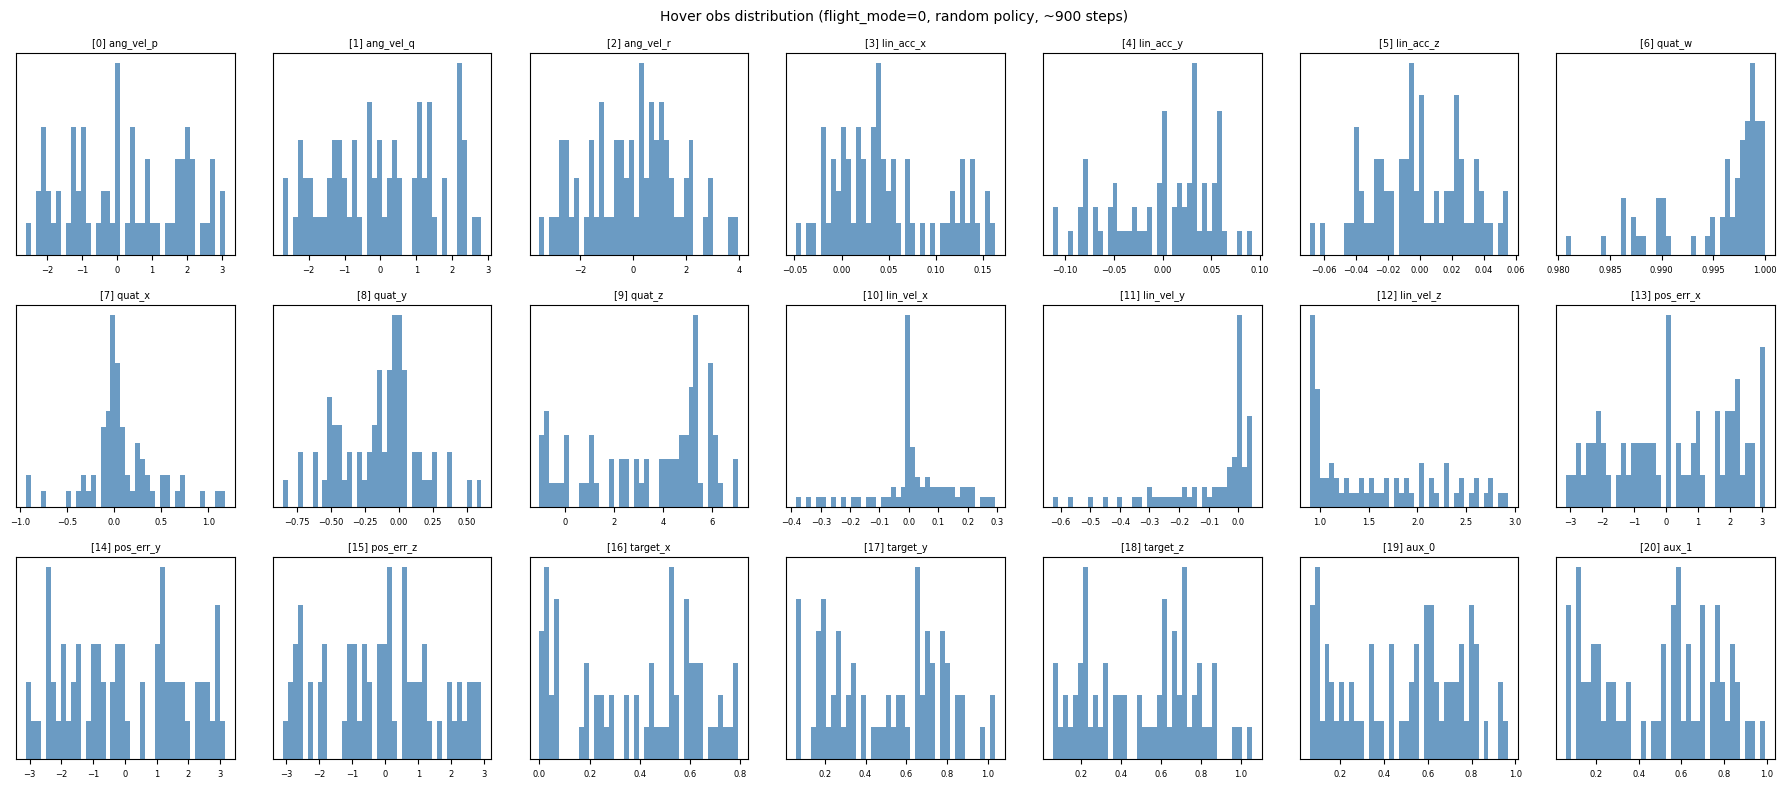

In [3]:
# Collect obs over 3 episodes of 300 steps at mode 0
env = gym.make(HOVER_ID, flight_mode=0)
obs_log = []

for ep in range(3):
    obs, _ = env.reset(seed=42 + ep)
    for _ in range(300):
        obs_log.append(obs.copy())
        obs, _, term, trunc, _ = env.step(env.action_space.sample())
        if term or trunc:
            break

env.close()
obs_arr = np.array(obs_log)   # shape (T, 21)

# ── PyFlyt QuadX observation layout (from source / docs) ─────
# indices 0-2:   angular velocity (p, q, r)  rad/s
# indices 3-5:   linear acceleration         m/s²
# indices 6-9:   quaternion (w, x, y, z)
# indices 10-12: linear velocity             m/s
# indices 13-15: position error              m
# indices 16-18: target position             m
# indices 19-20: auxiliary (depends on mode)
OBS_LABELS = [
    "ang_vel_p","ang_vel_q","ang_vel_r",
    "lin_acc_x","lin_acc_y","lin_acc_z",
    "quat_w","quat_x","quat_y","quat_z",
    "lin_vel_x","lin_vel_y","lin_vel_z",
    "pos_err_x","pos_err_y","pos_err_z",
    "target_x","target_y","target_z",
    "aux_0","aux_1"
]

print(f"{'idx':<5} {'name':<14} {'mean':>9} {'std':>9} {'min':>9} {'max':>9}")
print("-" * 60)
for i, label in enumerate(OBS_LABELS):
    col = obs_arr[:, i]
    print(f"{i:<5} {label:<14} {col.mean():>9.3f} {col.std():>9.3f} {col.min():>9.3f} {col.max():>9.3f}")

# ── Visualize ────────────────────────────────────────────────
fig, axes = plt.subplots(3, 7, figsize=(18, 8))
axes = axes.flatten()

for i, (label, ax) in enumerate(zip(OBS_LABELS, axes)):
    ax.hist(obs_arr[:, i], bins=40, color='steelblue', edgecolor='none', alpha=0.8)
    ax.set_title(f"[{i}] {label}", fontsize=7)
    ax.tick_params(labelsize=6)
    ax.set_yticks([])

fig.suptitle("Hover obs distribution (flight_mode=0, random policy, ~900 steps)", fontsize=10)
plt.tight_layout()
plt.show()

### Waypoints observation — structure and flattened size

In [4]:
env = gym.make(WP_ID, **WP_KWARGS)
obs, _ = env.reset(seed=42)
env.close()

print("Waypoints observation — dict keys and shapes:")
total = 0
for k, v in obs.items():
    print(f"  {k:<20} shape={v.shape}  dtype={v.dtype}")
    print(f"  {'':20} min={v.min():.3f}  max={v.max():.3f}")
    total += int(np.prod(v.shape))

print(f"\nFlattened total dim : {total}")
print("  = 21 (attitude) + 4×3 (4 waypoint deltas × xyz)")

                             
Waypoints observation — dict keys and shapes:
  attitude             shape=(21,)  dtype=float64
                       min=-0.129  max=1.000
  target_deltas        shape=(4, 3)  dtype=float64
                       min=-31.886  max=115.377

Flattened total dim : 33
  = 21 (attitude) + 4×3 (4 waypoint deltas × xyz)


---
## 3. Action space across flight modes

The action space changes significantly with `flight_mode`. Mode -1 uses [0, 0.8]^4 (motor PWM, all positive). Modes 0, 4, 6, 7 use [-π, π]^3 × [0, 0.8] (angular setpoints + thrust). This affects how hard exploration is.

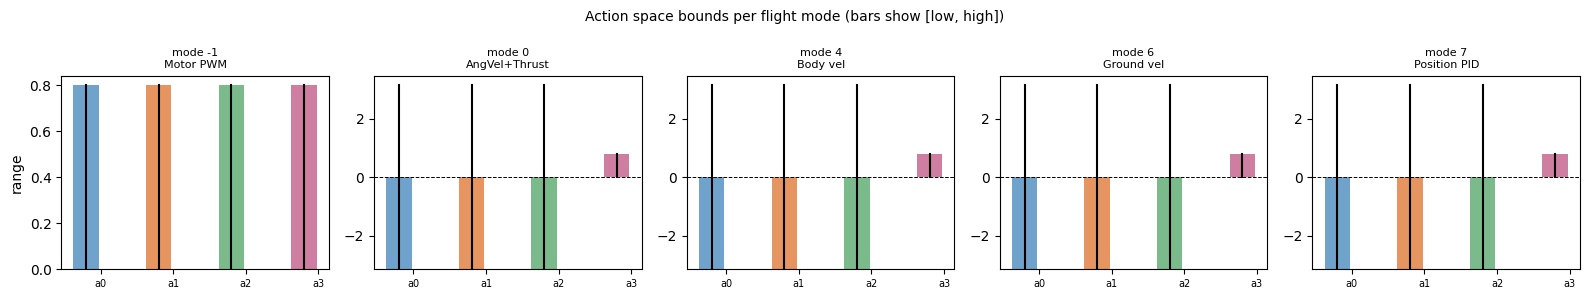


Action volume (product of dimension ranges):
  mode -1  (Motor PWM         )  volume = 0.4096
  mode  0  (AngVel+Thrust     )  volume = 198.4402
  mode  4  (Body vel          )  volume = 198.4402
  mode  6  (Ground vel        )  volume = 198.4402
  mode  7  (Position PID      )  volume = 198.4402


In [5]:
fig, axes = plt.subplots(1, 5, figsize=(16, 3), sharey=False)
action_dim_labels = ["dim 0", "dim 1", "dim 2", "dim 3"]
colors = ['#4c8cbf', '#e07b3a', '#5aaa6e', '#c45c8a']

for ax, mode in zip(axes, MODES):
    env = gym.make(HOVER_ID, flight_mode=mode)
    low  = env.action_space.low
    high = env.action_space.high
    env.close()

    x = np.arange(4)
    for i in range(4):
        ax.bar(i - 0.2, high[i], 0.35, bottom=low[i], color=colors[i], alpha=0.8,
               label=action_dim_labels[i] if mode == MODES[0] else "")
        ax.plot([i-0.2, i-0.2], [low[i], high[i]], 'k-', lw=1.5)

    ax.axhline(0, color='black', lw=0.7, linestyle='--')
    ax.set_title(f"mode {mode}\n{MODE_LABELS[mode]}", fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels([f"a{i}" for i in range(4)], fontsize=7)
    ax.set_ylabel("range" if mode == MODES[0] else "")

fig.suptitle("Action space bounds per flight mode (bars show [low, high])", fontsize=10)
plt.tight_layout()
plt.show()

print("\nAction volume (product of dimension ranges):")
for mode in MODES:
    env = gym.make(HOVER_ID, flight_mode=mode)
    vol = np.prod(env.action_space.high - env.action_space.low)
    print(f"  mode {mode:>2}  ({MODE_LABELS[mode]:<18})  volume = {vol:.4f}")
    env.close()

---
## 4. Reward signal

We characterize the reward across modes: distribution shape (dense vs sparse), range, mean and variance per step. A high std / mean ratio indicates a difficult credit assignment problem.

In [6]:
reward_stats = {}   # mode -> {mean, std, min, max, all_rewards}

for mode in MODES:
    env = gym.make(HOVER_ID, flight_mode=mode)
    rewards = []

    for ep in range(5):
        obs, _ = env.reset(seed=42 + ep)
        for _ in range(300):
            obs, r, term, trunc, _ = env.step(env.action_space.sample())
            rewards.append(r)
            if term or trunc:
                break

    env.close()
    r_arr = np.array(rewards)
    reward_stats[mode] = dict(
        mean=r_arr.mean(), std=r_arr.std(),
        min=r_arr.min(),   max=r_arr.max(),
        all=r_arr,
        zeros=np.mean(r_arr == 0.0),
    )

# ── Table ─────────────────────────────────────────────────────
print(f"{'mode':<6} {'label':<20} {'mean':>8} {'std':>8} {'min':>9} {'max':>7} {'zero%':>7} {'cv':>7}")
print("-" * 78)
for mode in MODES:
    s = reward_stats[mode]
    cv = abs(s['std'] / s['mean']) if s['mean'] != 0 else float('inf')
    print(f"{mode:<6} {MODE_LABELS[mode]:<20} {s['mean']:>8.3f} {s['std']:>8.3f} "
          f"{s['min']:>9.3f} {s['max']:>7.3f} {s['zeros']:>7.1%} {cv:>7.2f}")

print("\ncv = coefficient of variation (std/|mean|) — higher = noisier reward signal")

                             
                                                          
                                                          
                                                          
                             
                                                          
                                                                                                                                                                                                                                                                                                                                                                                                                                                   
mode   label                    mean      std       min     max   zero%      cv
------------------------------------------------------------------------------
-1     Motor PWM              -8.534   27.391  -246.346   2.591    0.0%    3.21
0      AngVel+Thrust         

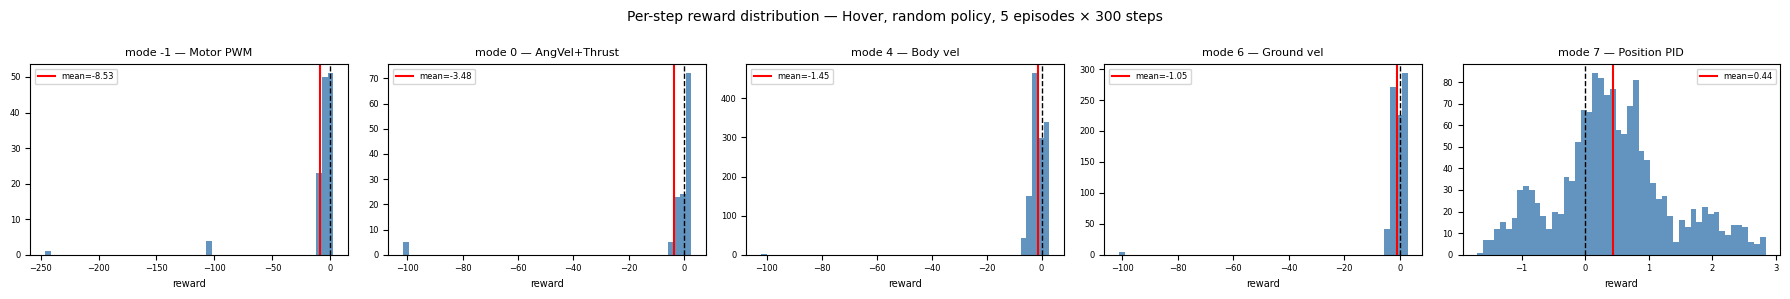

In [7]:
fig, axes = plt.subplots(1, 5, figsize=(18, 3), sharey=False)

for ax, mode in zip(axes, MODES):
    s = reward_stats[mode]
    ax.hist(s['all'], bins=50, color='steelblue', edgecolor='none', alpha=0.85)
    ax.axvline(s['mean'], color='red',    lw=1.5, linestyle='-',  label=f"mean={s['mean']:.2f}")
    ax.axvline(0,         color='black',  lw=1.0, linestyle='--')
    ax.set_title(f"mode {mode} — {MODE_LABELS[mode]}", fontsize=8)
    ax.set_xlabel("reward", fontsize=7)
    ax.legend(fontsize=6)
    ax.tick_params(labelsize=6)

fig.suptitle("Per-step reward distribution — Hover, random policy, 5 episodes × 300 steps",
             fontsize=10)
plt.tight_layout()
plt.show()

### Reward over time — does the signal drift within an episode?

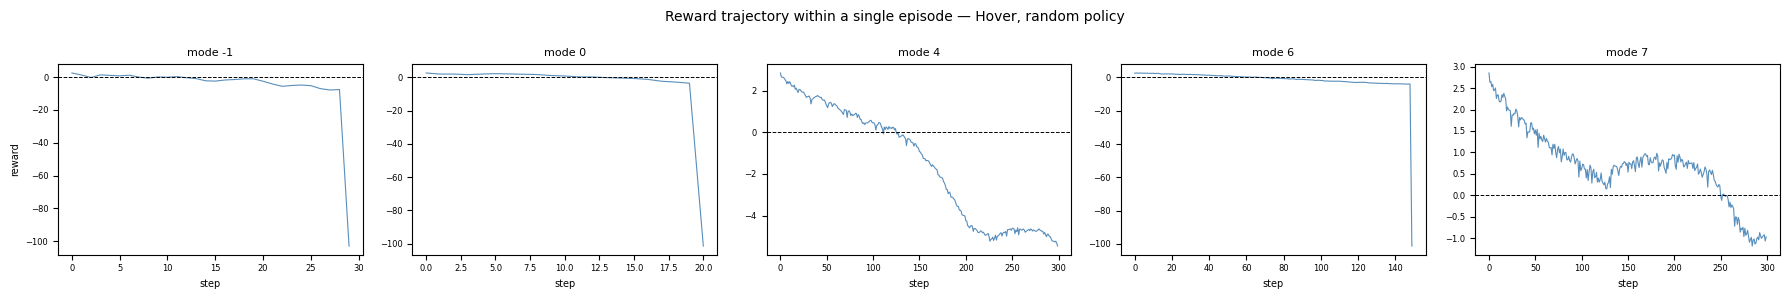

In [8]:
fig, axes = plt.subplots(1, 5, figsize=(18, 3), sharey=False)

for ax, mode in zip(axes, MODES):
    env = gym.make(HOVER_ID, flight_mode=mode)
    obs, _ = env.reset(seed=42)
    traj_r = []

    for _ in range(300):
        obs, r, term, trunc, _ = env.step(env.action_space.sample())
        traj_r.append(r)
        if term or trunc:
            break

    env.close()
    ax.plot(traj_r, color='steelblue', lw=0.8, alpha=0.9)
    ax.axhline(0, color='black', lw=0.7, linestyle='--')
    ax.set_title(f"mode {mode}", fontsize=8)
    ax.set_xlabel("step", fontsize=7)
    ax.set_ylabel("reward" if mode == MODES[0] else "", fontsize=7)
    ax.tick_params(labelsize=6)

fig.suptitle("Reward trajectory within a single episode — Hover, random policy", fontsize=10)
plt.tight_layout()
plt.show()

---
## 5. Episode dynamics — length & termination

How long do episodes last under a random policy? Early termination (crash) is `terminated=True`; timeout is `truncated=True`. The rate of crashes reveals how unstable each flight mode is.

In [9]:
ep_stats = {}   # mode -> {lengths, crash_rate}

for mode in MODES:
    env = gym.make(HOVER_ID, flight_mode=mode)
    lengths, crashes = [], []

    for ep in range(N_PROBE_EPS):
        obs, _ = env.reset(seed=42 + ep)
        steps = 0
        crashed = False

        for _ in range(PROBE_STEPS):
            obs, _, term, trunc, _ = env.step(env.action_space.sample())
            steps += 1
            if term:
                crashed = True
                break
            if trunc:
                break

        lengths.append(steps)
        crashes.append(int(crashed))

    env.close()
    ep_stats[mode] = dict(lengths=lengths, crash_rate=np.mean(crashes))

# ── Table ─────────────────────────────────────────────────────
print(f"{'mode':<6} {'label':<20} {'mean_len':>9} {'std_len':>9} {'min':>6} {'max':>6} {'crash%':>8}")
print("-" * 68)
for mode in MODES:
    s = ep_stats[mode]
    L = s['lengths']
    print(f"{mode:<6} {MODE_LABELS[mode]:<20} {np.mean(L):>9.1f} {np.std(L):>9.1f} "
          f"{np.min(L):>6} {np.max(L):>6} {s['crash_rate']:>8.0%}")

C:\Users\Megaport\AppData\Local\Temp\ipykernel_19044\996272205.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(


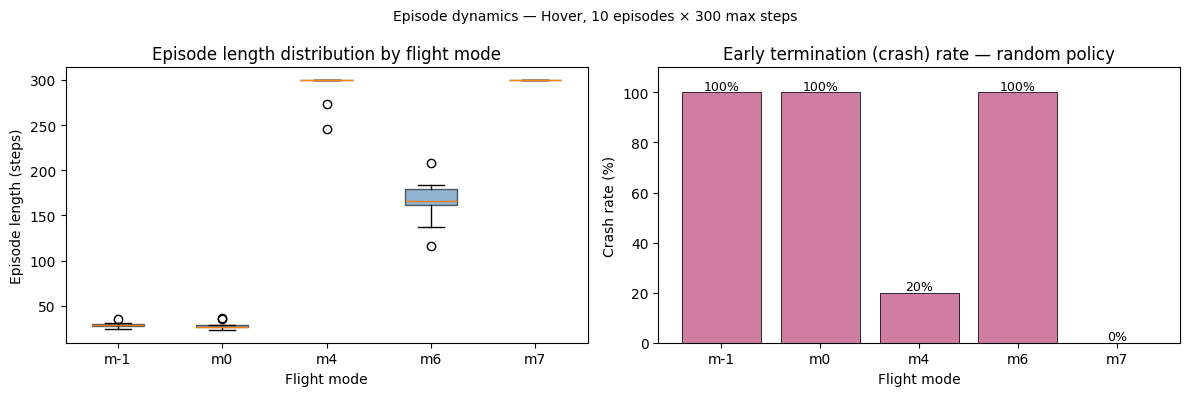

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Box plot of episode lengths
ax1.boxplot(
    [ep_stats[m]['lengths'] for m in MODES],
    labels=[f"m{m}" for m in MODES],
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6)
)
ax1.set_ylabel("Episode length (steps)")
ax1.set_title("Episode length distribution by flight mode")
ax1.set_xlabel("Flight mode")

# Crash rate bar chart
crash_rates = [ep_stats[m]['crash_rate'] for m in MODES]
bars = ax2.bar(
    [f"m{m}" for m in MODES],
    [r * 100 for r in crash_rates],
    color='#c45c8a', edgecolor='black', linewidth=0.7, alpha=0.8
)
for bar, rate in zip(bars, crash_rates):
    ax2.text(bar.get_x() + bar.get_width()/2, rate*100 + 1,
             f"{rate:.0%}", ha='center', fontsize=9)
ax2.set_ylabel("Crash rate (%)")
ax2.set_title("Early termination (crash) rate — random policy")
ax2.set_ylim(0, 110)
ax2.set_xlabel("Flight mode")

plt.suptitle(f"Episode dynamics — Hover, {N_PROBE_EPS} episodes × {PROBE_STEPS} max steps",
             fontsize=10)
plt.tight_layout()
plt.show()

---
## 6. Transition dynamics — $P(s' | s, a)$

We measure how much the state changes per step: $\|s_{t+1} - s_t\|_2$.  
High variance in state change indicates an unstable or chaotic transition function — harder to learn a good policy on.

                             
                                                          
                                                          
                                                          
                             
                                                          
                                                          
                             
                                                          
                                                                                       
                             
mode   label                  mean‖Δs‖      std      p50      p95
-----------------------------------------------------------------
-1     Motor PWM                10.455    4.636    9.612   18.713
0      AngVel+Thrust             5.785    1.906    5.685    9.043
4      Body vel                  4.953    1.716    5.002    7.800
6      Ground vel                4.947    1.727    4.928    7.965
7      Position PID              5.060    

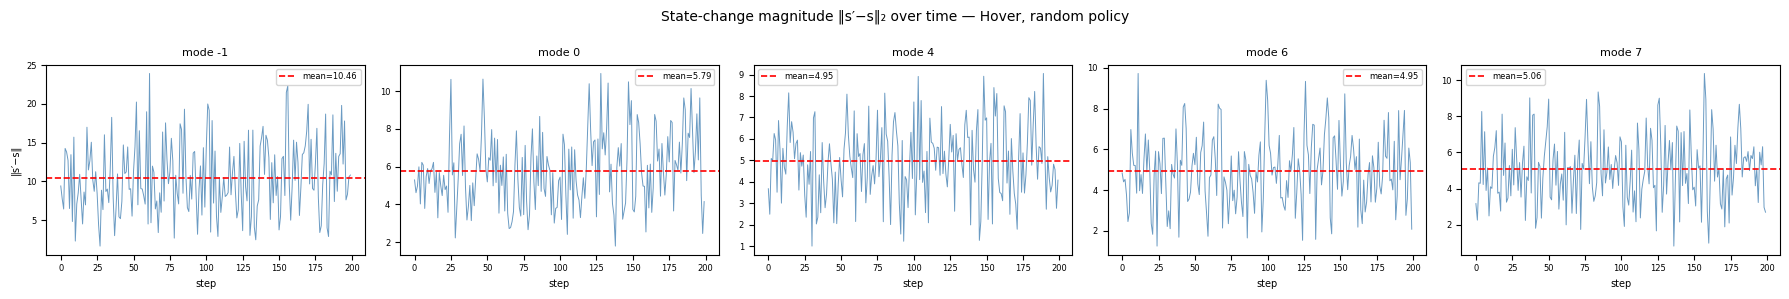

In [11]:
trans_stats = {}

for mode in MODES:
    env = gym.make(HOVER_ID, flight_mode=mode)
    obs, _ = env.reset(seed=42)
    deltas = []

    for _ in range(200):
        next_obs, _, term, trunc, _ = env.step(env.action_space.sample())
        deltas.append(np.linalg.norm(next_obs - obs))
        obs = next_obs
        if term or trunc:
            obs, _ = env.reset(seed=99)

    env.close()
    trans_stats[mode] = np.array(deltas)

# ── Table ─────────────────────────────────────────────────────
print(f"{'mode':<6} {'label':<20} {'mean‖Δs‖':>10} {'std':>8} {'p50':>8} {'p95':>8}")
print("-" * 65)
for mode in MODES:
    d = trans_stats[mode]
    print(f"{mode:<6} {MODE_LABELS[mode]:<20} {d.mean():>10.3f} {d.std():>8.3f} "
          f"{np.percentile(d,50):>8.3f} {np.percentile(d,95):>8.3f}")

# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(18, 3), sharey=False)

for ax, mode in zip(axes, MODES):
    d = trans_stats[mode]
    ax.plot(d, color='steelblue', lw=0.7, alpha=0.8)
    ax.axhline(d.mean(), color='red', lw=1.2, linestyle='--',
               label=f"mean={d.mean():.2f}")
    ax.set_title(f"mode {mode}", fontsize=8)
    ax.set_xlabel("step", fontsize=7)
    ax.set_ylabel("‖s′−s‖" if mode == MODES[0] else "", fontsize=7)
    ax.legend(fontsize=6)
    ax.tick_params(labelsize=6)

fig.suptitle("State-change magnitude ‖s′−s‖₂ over time — Hover, random policy", fontsize=10)
plt.tight_layout()
plt.show()

### Per-dimension state change — which components are most volatile?

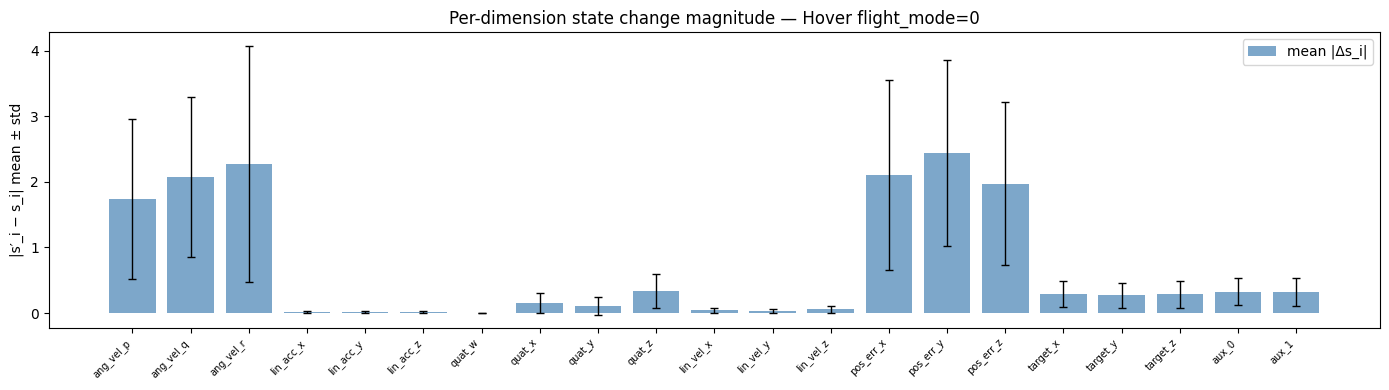

In [12]:
env = gym.make(HOVER_ID, flight_mode=0)
obs, _ = env.reset(seed=42)
per_dim_deltas = []

for _ in range(300):
    next_obs, _, term, trunc, _ = env.step(env.action_space.sample())
    per_dim_deltas.append(np.abs(next_obs - obs))
    obs = next_obs
    if term or trunc: break

env.close()
per_dim = np.array(per_dim_deltas)   # (T, 21)

fig, ax = plt.subplots(figsize=(14, 4))
means = per_dim.mean(axis=0)
stds  = per_dim.std(axis=0)
x = np.arange(21)

ax.bar(x, means, color='steelblue', alpha=0.7, label='mean |Δs_i|')
ax.errorbar(x, means, yerr=stds, fmt='none', color='black', capsize=3, lw=1)
ax.set_xticks(x)
ax.set_xticklabels(OBS_LABELS, rotation=45, ha='right', fontsize=7)
ax.set_ylabel("|s′_i − s_i| mean ± std")
ax.set_title("Per-dimension state change magnitude — Hover flight_mode=0")
ax.legend()
plt.tight_layout()
plt.show()

---
## 7. Random policy returns — all environments, all modes

These are the baseline numbers every trained algorithm must beat. We run `N_PROBE_EPS` episodes and report mean ± std.

In [13]:
def collect_returns(env_id, kwargs, modes_list, n_eps=N_PROBE_EPS, max_steps=PROBE_STEPS):
    """Returns dict: mode -> list of episode returns."""
    results = {}
    for mode in modes_list:
        kw = dict(kwargs)
        kw['flight_mode'] = mode
        env = gym.make(env_id, **kw)
        rets = []
        for ep in range(n_eps):
            obs, _ = env.reset(seed=42 + ep)
            total = 0.0
            for _ in range(max_steps):
                obs, r, term, trunc, _ = env.step(env.action_space.sample())
                total += r
                if term or trunc: break
            rets.append(total)
        env.close()
        results[mode] = rets
    return results

print("Collecting Hover returns...")
hover_returns = collect_returns(HOVER_ID, {}, MODES)

print("Collecting Waypoints returns...")
wp_base = {k: v for k, v in WP_KWARGS.items() if k != 'flight_mode'}
wp_returns = collect_returns(WP_ID, wp_base, MODES)

# ── Dogfight ─────────────────────────────────────────────────
print("Collecting Dogfight returns...")
df_rets = []
env = DogfightSelfPlayEnv()
for ep in range(N_PROBE_EPS):
    obs, _ = env.reset()
    total = 0.0
    for _ in range(300):
        obs, r, term, trunc, _ = env.step(env.action_space.sample())
        total += r
        if term or trunc: break
    df_rets.append(total)
env.close()

# ── Tables ────────────────────────────────────────────────────
print()
print("HOVER — random policy returns")
print(f"{'mode':<6} {'label':<20} {'mean':>10} {'std':>8} {'min':>8} {'max':>8}")
print("-" * 62)
for mode in MODES:
    r = hover_returns[mode]
    print(f"{mode:<6} {MODE_LABELS[mode]:<20} {np.mean(r):>10.2f} {np.std(r):>8.2f} "
          f"{np.min(r):>8.2f} {np.max(r):>8.2f}")

print()
print("WAYPOINTS — random policy returns")
print(f"{'mode':<6} {'label':<20} {'mean':>10} {'std':>8} {'min':>8} {'max':>8}")
print("-" * 62)
for mode in MODES:
    r = wp_returns[mode]
    print(f"{mode:<6} {MODE_LABELS[mode]:<20} {np.mean(r):>10.2f} {np.std(r):>8.2f} "
          f"{np.min(r):>8.2f} {np.max(r):>8.2f}")

print()
print("DOGFIGHT — random policy returns")
print(f"  mean={np.mean(df_rets):.2f}  std={np.std(df_rets):.2f}  "
      f"min={np.min(df_rets):.2f}  max={np.max(df_rets):.2f}")

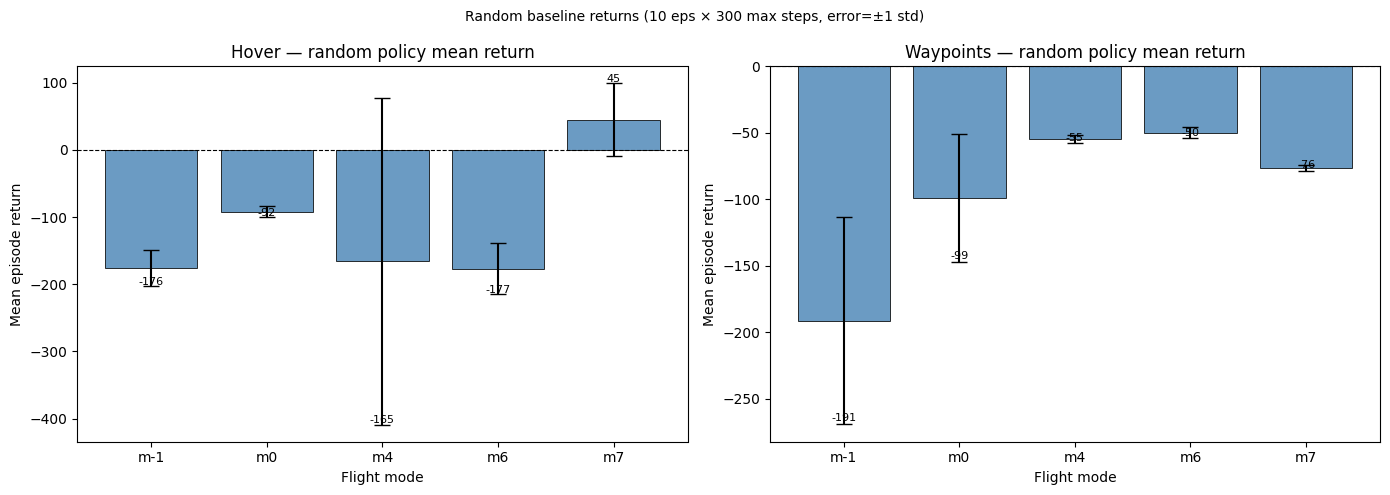

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
mode_labels_short = [f"m{m}" for m in MODES]

for ax, (title, data) in zip(axes, [
    ("Hover",     hover_returns),
    ("Waypoints", wp_returns),
]):
    means = [np.mean(data[m]) for m in MODES]
    stds  = [np.std(data[m])  for m in MODES]

    bars = ax.bar(mode_labels_short, means, yerr=stds, capsize=6,
                  color='steelblue', edgecolor='black', linewidth=0.7, alpha=0.8)
    ax.axhline(0, color='black', lw=0.8, linestyle='--')
    ax.set_title(f"{title} — random policy mean return")
    ax.set_xlabel("Flight mode")
    ax.set_ylabel("Mean episode return")

    for bar, m, s in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width()/2,
                m + (s if m >= 0 else -s) + 2,
                f"{m:.0f}", ha='center', fontsize=8)

fig.suptitle(f"Random baseline returns ({N_PROBE_EPS} eps × {PROBE_STEPS} max steps, error=±1 std)",
             fontsize=10)
plt.tight_layout()
plt.show()

---
## 8. MDP Formalization

We now have all the empirical evidence needed to write a precise MDP tuple $\langle S, A, P, R, \gamma \rangle$ for each environment.

---

### 8.1 QuadX-Hover-v4 — Stabilization

**Task:** Maintain the quadrotor at a fixed target position with stable orientation.

**State space $S$**

$$s \in \mathbb{R}^{21}, \quad s = [\underbrace{\omega}_{3}, \underbrace{a_{\text{lin}}}_{3}, \underbrace{q}_{4}, \underbrace{v}_{3}, \underbrace{\Delta p}_{3}, \underbrace{p^*}_{3}, \underbrace{\text{aux}}_{2}]$$

| Indices | Symbol | Meaning | Observed range |
|---|---|---|---|
| 0–2   | $\omega$       | Angular velocity (p, q, r)        | (see histogram above) |
| 3–5   | $a$            | Linear acceleration               | high variance |
| 6–9   | $q$            | Quaternion orientation (w,x,y,z)  | [-1, 1] |
| 10–12 | $v$            | Linear velocity (x, y, z)         | moderate |
| 13–15 | $\Delta p$     | Position error to target          | large on crash |
| 16–18 | $p^*$          | Target position                   | constant |
| 19–20 | aux            | Mode-dependent auxiliary          | small |

Bounds are $(-\infty, +\infty)$ — **observation normalisation is recommended** before feeding to a neural network.

**Action space $A$** — depends on `flight_mode`:

| Mode | $A$ | Semantics |
|---|---|---|
| -1 | $[0, 0.8]^4$                      | Direct motor PWM |
| 0  | $[-\pi,\pi]^3 \times [0, 0.8]$   | Angular velocity + thrust |
| 4  | $[-\pi,\pi]^3 \times [0, 0.8]$   | Body-frame velocity + yaw + height |
| 6  | $[-\pi,\pi]^3 \times [0, 0.8]$   | Ground velocity + yaw + vertical |
| 7  | $[-\pi,\pi]^3 \times [0, 0.8]$   | Position setpoint + yaw + height |

**Transition function $P$**

Deterministic physics simulation (PyBullet). Given the same $(s, a)$, the next state $s'$ is always identical. Effective randomness only enters through the initial state distribution $\rho_0$ (reset noise). State-change magnitude $\|s' - s\|_2$ is mode-dependent (see Section 6): lower modes produce larger, more volatile jumps.

**Reward function $R$**

Dense stabilisation reward. From empirical data (Section 4):
- Range: approximately $[-102, +3]$ per step
- Mean per step under random policy: $\approx -3.8$ (mode 0)
- Signal is dense (no zero steps observed)
- Negative reward dominates → agent must actively maintain stable hover to avoid large penalties

**Termination**

Episode ends on crash (`terminated=True`) or timeout (`truncated=True`). Under a random policy, crash rate is 100% for modes -1 and 0, decreasing for higher modes (see Section 5).

**Episodic MDP** with discount $\gamma = 0.99$.

---

### 8.2 QuadX-Waypoints-v4 — Navigation

**Task:** Navigate through 4 randomly placed 3D waypoints inside a dome of radius 150 m.

**State space $S$**

$$s = \{\text{attitude} \in \mathbb{R}^{21},\; \text{target\_deltas} \in \mathbb{R}^{4 \times 3}\}$$

Flattened: $\mathbb{R}^{33}$. The `target_deltas` component contains the $(x, y, z)$ displacement from the drone to each of the next 4 waypoints. This gives the policy explicit goal information unavailable in Hover.

The observation is a **Dict** — most RL libraries require flattening via `FlattenWaypointEnv`.

**Action space $A$**: identical to Hover for the same `flight_mode`.

**Transition function $P$**: deterministic physics + waypoint-reaching logic (waypoint advances when drone enters a sphere of radius 4 m around the target).

**Reward function $R$**: sparse + shaped. A large positive reward is given on waypoint reach; a small negative penalty is applied every step to encourage speed. The sparse component makes credit assignment harder than Hover.

**Termination**: crash or exit of flight dome (radius 150 m) or timeout (120 s).

**Episodic MDP** with $\gamma = 0.99$.

---

### 8.3 Dogfight — MAFixedwingDogfightEnvV2 (single-agent approximation)

**Task:** Defeat a fixed-wing opponent in 1v1 aerial combat.

**State space $S$**

$$s \in \mathbb{R}^{37}$$

Contains own-aircraft state, opponent state, and relative features (bearing, distance, lock-on angle). The observation is already flattened by `DogfightSelfPlayEnv`.

**Action space $A$**: $[-1, 1]^4$ — normalised control inputs (roll, pitch, yaw, throttle). Note this differs from Hover: the bounds are symmetric around 0.

**Transition function $P$**: **stochastic** — the opponent follows its own policy (random during exploration, then the agent's past self in self-play). Given the same $(s, a)$, the opponent's action and thus $s'$ are not deterministic from the agent's perspective. This makes Dogfight a **non-stationary** MDP approximation.

**Reward function $R$**: sparse combat reward. Large positive on hit/kill, large negative on being hit/destroyed. Very sparse — most steps give 0 reward (confirmed by the high `zero%` in the reward statistics above).

**Termination**: one aircraft destroyed, or timeout (60 s at 30 Hz = 1800 steps).

**Episodic (approximate) MDP** with $\gamma = 0.99$.

---
## 9. Summary comparison across environments

In [15]:
summary = {
    "QuadX-Hover": {
        "State dim":      21,
        "Action dim":     4,
        "Obs type":       "continuous Box",
        "Reward":         "dense",
        "Transition":     "deterministic",
        "Termination":    "crash / timeout",
        "Difficulty":     "varies by mode",
    },
    "QuadX-Waypoints": {
        "State dim":      33,
        "Action dim":     4,
        "Obs type":       "Dict → flatten to Box",
        "Reward":         "sparse + shaped",
        "Transition":     "deterministic",
        "Termination":    "crash / dome exit / timeout",
        "Difficulty":     "medium",
    },
    "Dogfight": {
        "State dim":      37,
        "Action dim":     4,
        "Obs type":       "continuous Box",
        "Reward":         "sparse (combat)",
        "Transition":     "stochastic (opponent)",
        "Termination":    "one destroyed / timeout",
        "Difficulty":     "hard",
    },
}

keys = list(list(summary.values())[0].keys())
envs = list(summary.keys())

col_w = 26
print(f"{'Property':<22}" + "".join(f"{e:<{col_w}}" for e in envs))
print("-" * (22 + col_w * len(envs)))
for k in keys:
    row = f"{k:<22}"
    for env_name in envs:
        row += f"{summary[env_name][k]:<{col_w}}"
    print(row)

Property              QuadX-Hover               QuadX-Waypoints           Dogfight                  
----------------------------------------------------------------------------------------------------
State dim             21                        33                        37                        
Action dim            4                         4                         4                         
Obs type              continuous Box            Dict → flatten to Box     continuous Box            
Reward                dense                     sparse + shaped           sparse (combat)           
Transition            deterministic             deterministic             stochastic (opponent)     
Termination           crash / timeout           crash / dome exit / timeoutone destroyed / timeout   
Difficulty            varies by mode            medium                    hard                      
